In [2]:
pip install pandas numpy scikit-learn matplotlib seaborn lime shap

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 546.9/546.9 kB 1.6 MB/s eta 0:00:00-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 2.3 MB/s eta 0:00:00a 0:00:01
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=e0761f3629ef536a5053ae797fb7e65cb28cebbc6866c8f52c3585313c0b8000
  Stored in directory: /Users/ilyayakushevskiy/Library/Caches/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime

[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

import lime
import lime.lime_tabular
import shap

warnings.filterwarnings("ignore")

In [136]:
# Load a CSV file

full = pd.read_csv("../Sat Data/avalanche+sat+depth+weather_all.csv",
    dtype={91: str})





In [137]:
# Basic info
print(full.info())  # data types, missing values
print(full.head())  # first few rows
print(full.describe())  # statistics for numerical columns

# Check for missing values
print(full.isnull().sum())
print(len(full.columns))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1012 entries, 0 to 1011
Data columns (total 51 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   avalanche_id                     1012 non-null   object 
 1   location                         1012 non-null   object 
 2   trigger_date_time                1012 non-null   object 
 3   trigger_date_time_accuracy_code  1012 non-null   int64  
 4   trigger_type                     1012 non-null   object 
 5   avalanche_type                   1012 non-null   object 
 6   avalanche_size                   1012 non-null   int64  
 7   avalanche_moisture               1012 non-null   object 
 8   start_zone_aspect                958 non-null    object 
 9   snow_depth_sat                   1012 non-null   int64  
 10  lat                              1012 non-null   float64
 11  lon                              1012 non-null   float64
 12  Avalanche Event     

In [138]:
#Clean the dataset (no NA, no non numerical, no Year, no datum)

# Drop columns with >20% missing
full_clean = full.dropna(thresh=len(full) * 0.8, axis=1)

# Remove rows with any missing values
full_clean = full_clean.dropna()

# Exclude "year' and 'datum'
full_clean = full_clean.drop(columns=[col for col in ['year', 'datum'] if col in full_clean.columns])

# Keep only numeric columns
full_clean = full_clean.select_dtypes(include=[np.number])


In [139]:
print(len(full_clean.columns))

full_clean.drop(columns=["lon","lat", "trigger_date_time_accuracy_code", "avalanche_size", ], inplace=True, errors='ignore')

full_clean.head()
len(full_clean)

#drop 'gradient_x', 'aspect', 'fkl010h1', 'prestah0', 'tre200h0', 'tre200hn', 'fu3010h3', 'fu3010h1', 'pva200h0', 'fkl010h3'
print(full_clean.columns)
#full_clean.drop(columns=['gradient_x', 'aspect', 'fkl010h1', 'prestah0', 'tre200h0', 'tre200hn', 'fu3010h3', 'fu3010h1', 'pva200h0', 'fkl010h3'], inplace=True, errors='ignore')
full_clean.head()




28
Index(['snow_depth_sat', 'Avalanche Event', 'elevation', 'gradient_x',
       'gradient_y', 'gradient_magnitude', 'aspect', 'tre200h0', 'tre200hn',
       'tre200hx', 'ure200h0', 'pva200h0', 'tde200h0', 'prestah0', 'pp0qnhh0',
       'fkl010h1', 'dkl010h0', 'fkl010h0', 'fu3010h0', 'fu3010h1', 'fkl010h3',
       'fu3010h3', 'gre000h0', 'erefaoh0'],
      dtype='object')


,snow_depth_sat,Avalanche Event,elevation,gradient_x,gradient_y,gradient_magnitude,aspect,tre200h0,tre200hn,tre200hx,...,pp0qnhh0,fkl010h1,dkl010h0,fkl010h0,fu3010h0,fu3010h1,fkl010h3,fu3010h3,gre000h0,erefaoh0
0,0,0,663.537537,253.454590,-223.022461,337.606646,228.654462,5.2,4.8,5.5,...,1019.1,11.9,332.0,4.8,17.3,42.8,11.2,40.3,847.0,0.327
1,0,0,758.959473,240.490723,-189.184570,305.984623,231.809266,7.0,5.8,8.3,...,1019.2,4.8,204.0,1.9,6.8,17.3,4.1,14.8,545.0,0.227
2,164,0,650.577576,-1095.886230,1869.323730,2166.872825,30.380854,-2.5,-2.9,-1.8,...,1027.0,3.8,307.0,2.1,7.6,13.7,3.8,13.7,790.0,0.277
4,287,0,635.661621,158.312988,1683.764648,1691.190821,354.628657,-1.7,-1.9,-1.4,...,1026.3,6.4,150.0,5.3,19.1,23.0,6.3,22.7,705.0,0.218
5,39,0,686.813721,403.198242,-696.093750,804.434790,210.080701,11.4,10.4,12.2,...,1009.0,8.9,233.0,3.9,14.0,32.0,8.6,31.0,426.0,0.247


In [140]:
print(full_clean['Avalanche Event'].value_counts())


Avalanche Event
0    795
1    116
Name: count, dtype: int64


In [156]:
#RANDOM SPLIT (Could also leave out year 2022)

# Split features and target
# X = full_clean.drop(columns=["Avalanche Event"])   # all columns except the target
# y = full_clean["Avalanche Event"]  # avalanche label: 1 = avalanche, 0 = no avalanche


X = full_clean.drop(columns=["Avalanche Event"])   # all columns except the target
y = full_clean["Avalanche Event"]


# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (mean=0, std=1) - to normalize units
scaler = StandardScaler()
sample_weight = (X_train['snow_depth_sat'] > 0).astype(float)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X.columns


Index(['snow_depth_sat', 'elevation', 'gradient_x', 'gradient_y',
       'gradient_magnitude', 'aspect', 'tre200h0', 'tre200hn', 'tre200hx',
       'ure200h0', 'pva200h0', 'tde200h0', 'prestah0', 'pp0qnhh0', 'fkl010h1',
       'dkl010h0', 'fkl010h0', 'fu3010h0', 'fu3010h1', 'fkl010h3', 'fu3010h3',
       'gre000h0', 'erefaoh0'],
      dtype='object')

In [142]:
# Print the shapes of the datasets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
np.sum(y_test)

X_train shape: (728, 23)
X_test shape: (183, 23)
y_train shape: (728,)
y_test shape: (183,)


17

# Random Forest 

              precision    recall  f1-score   support

No Avalanche       0.96      0.87      0.91       166
   Avalanche       0.33      0.65      0.44        17

    accuracy                           0.85       183
   macro avg       0.65      0.76      0.68       183
weighted avg       0.90      0.85      0.87       183



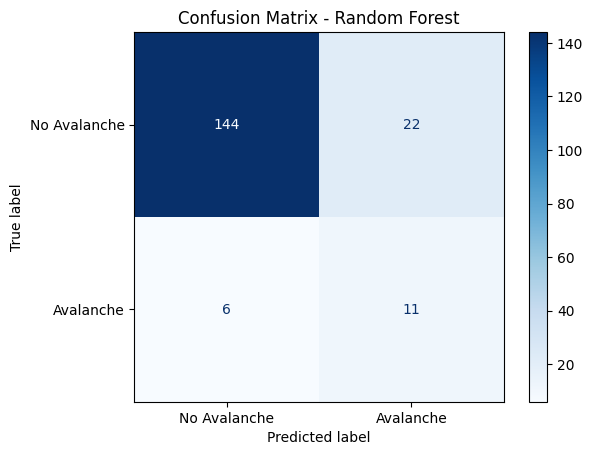

In [143]:
# Train Random Forest Classifier (F1 optimized)

#Best parameters: {'class_weight': None, 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 5, 'n_estimators': 100}
#Best parameters: {'class_weight': {0: 1, 1: 9}, 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 10, 'n_estimators': 50} Best F1 score: 0.61151692094557
rf_custom_F1 = RandomForestClassifier(
    class_weight= {0: 1, 1: 9},
    max_depth=20,
    max_features=None,
    min_samples_leaf=10,
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
# Train the model
rf_custom_F1.fit(X_train_scaled, y_train)
# Predict on test set
y_pred_F1 = rf_custom_F1.predict(X_test_scaled)


#Evaluate Model
print(classification_report(y_test, y_pred_F1, target_names=["No Avalanche", "Avalanche"]))
cm = confusion_matrix(y_test, y_pred_F1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Avalanche", "Avalanche"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

#True Negatives (TN): 1921 → Correctly predicted no avalanche
#False Positives (FP): 2 → Predicted avalanche, but none happened (In real world - OK - better safe than sorry)
#False Negatives (FN): 16 → Predicted no avalanche, but avalanche happened (NOT GOOD)
#True Positives (TP): 120 → Correctly predicted avalanche 

#Precision (Avalanche): 0.97  
#97% of predicted avalanches were correct

# Recall (Avalanche): 0.88
# 88% of actual avalanches were detected

# F1 Score (Avalanche): 0.92
# Very strong harmonic mean of precision & recall.

# Overall Accuracy: 0.99 (amazing — but secondary to look at for risk prediction)
# Why risk prediction: 
# Accuracy can be misleading, especially when the event you're trying to predict (like an avalanche) is rare == Avalanche
#How many avalanches did we NOT chatch - 12% !!!

In [144]:
# from sklearn.model_selection import GridSearchCV
# #Hyperparameter tuning - find the best parameters for our RF
# param_grid = {
#     'max_features': ['sqrt', 'log2', None],
#     'class_weight': ['balanced', None, {0: 1, 1: 9}],
#     'max_depth': [2,3,5,10,20],
#     'min_samples_leaf': [5,10,20,50,100,200],
#     'n_estimators': [10,25,30,50,100,200]
# }

# grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
#                            param_grid,
#                            cv=4,
#                            scoring='f1',
#                            n_jobs=-1,
#                            verbose=1)

# grid_search.fit(X_train_scaled, y_train)
# print("Best parameters:", grid_search.best_params_)
# print("Best F1 score:", grid_search.best_score_)



In [147]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'max_depth': [2, 3, 5, 10, 20],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [10, 30, 50, 100],
    'scale_pos_weight': [1, 5, 9],  # class imbalance handling
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Create the model
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1',
    cv=4,
    verbose=1,
    n_jobs=-1
)

# Run grid search
grid_search.fit(X_train_scaled, y_train)

# Output the best results
print("Best parameters:", grid_search.best_params_)
print("Best F1 score:", grid_search.best_score_)


Fitting 4 folds for each of 720 candidates, totalling 2880 fits


/Users/ilyayakushevskiy/.pyenv/versions/3.12.0/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [19:07:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/ilyayakushevskiy/.pyenv/versions/3.12.0/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [19:07:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/ilyayakushevskiy/.pyenv/versions/3.12.0/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [19:07:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/ilyayakushevskiy/.pyenv/versions/3.12.0/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [19:07:24] WARNING: /Users/runn

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 20, 'n_estimators': 100, 'scale_pos_weight': 9, 'subsample': 1.0}
Best F1 score: 0.5980039096291658


In [145]:
print(X_train_scaled.shape , y_train.shape)

(728, 23) (728,)


              precision    recall  f1-score   support

No Avalanche       0.96      0.95      0.95       166
   Avalanche       0.56      0.59      0.57        17

    accuracy                           0.92       183
   macro avg       0.76      0.77      0.76       183
weighted avg       0.92      0.92      0.92       183



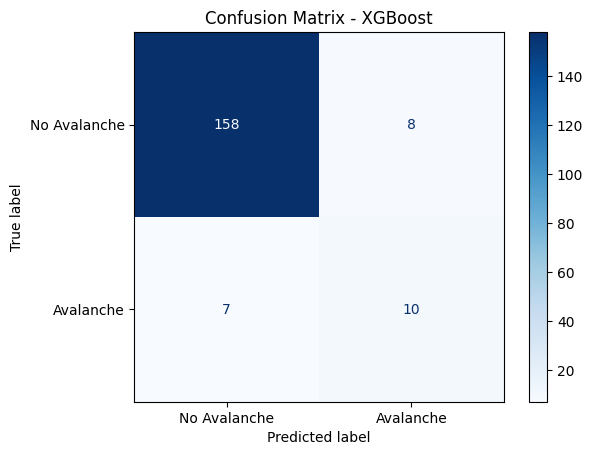

In [157]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 20, 'n_estimators': 100, 'scale_pos_weight': 9, 'subsample': 1.0
xgb_custom = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=9,  # Class imbalance: same effect as class_weight={0:1, 1:9}
    max_depth=20,
    n_estimators=100,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_custom.fit(X_train_scaled, y_train, sample_weight=sample_weight)





y_pred_xgb = xgb_custom.predict(X_test_scaled)

# Evaluate model
print(classification_report(y_test, y_pred_xgb, target_names=["No Avalanche", "Avalanche"]))
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Avalanche", "Avalanche"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.show()


### Predict the Map

In [160]:

map_df = pd.read_csv("../Sat Data/test_image+stations.csv")
lats = map_df['lat']
lons = map_df['lon']
map_df.drop(columns=["lon","lat", "trigger_date_time", "trigger_date_time", "closest_station", "station_abbr"], inplace=True, errors='ignore')
#full_clean.drop(columns=['gradient_x', 'aspect', 'fkl010h1', 'prestah0', 'tre200h0', 'tre200hn', 'fu3010h3', 'fu3010h1', 'pva200h0', 'fkl010h3'], inplace=True, errors='ignore')
map_df = map_df.dropna(thresh=len(full) * 0.8, axis=1)
map_df = map_df.select_dtypes(include=[np.number])
map_df = map_df.rename(columns={'gradient_mag': 'gradient_magnitude'})
map_df = map_df[['snow_depth_sat', 'elevation', 'gradient_x', 'gradient_y',
       'gradient_magnitude', 'aspect', 'tre200h0', 'tre200hn', 'tre200hx',
       'ure200h0', 'pva200h0', 'tde200h0', 'prestah0', 'pp0qnhh0', 'fkl010h1',
       'dkl010h0', 'fkl010h0', 'fu3010h0', 'fu3010h1', 'fkl010h3', 'fu3010h3',
       'gre000h0', 'erefaoh0']]

print(map_df.columns)
map_df.head()

X_train_scaled = scaler.fit_transform(map_df)

#y_map = rf_custom_F1.predict(X_train_scaled)
y_map_proba = rf_custom_F1.predict_proba(X_train_scaled)[:, 1]


Index(['snow_depth_sat', 'elevation', 'gradient_x', 'gradient_y',
       'gradient_magnitude', 'aspect', 'tre200h0', 'tre200hn', 'tre200hx',
       'ure200h0', 'pva200h0', 'tde200h0', 'prestah0', 'pp0qnhh0', 'fkl010h1',
       'dkl010h0', 'fkl010h0', 'fu3010h0', 'fu3010h1', 'fkl010h3', 'fu3010h3',
       'gre000h0', 'erefaoh0'],
      dtype='object')


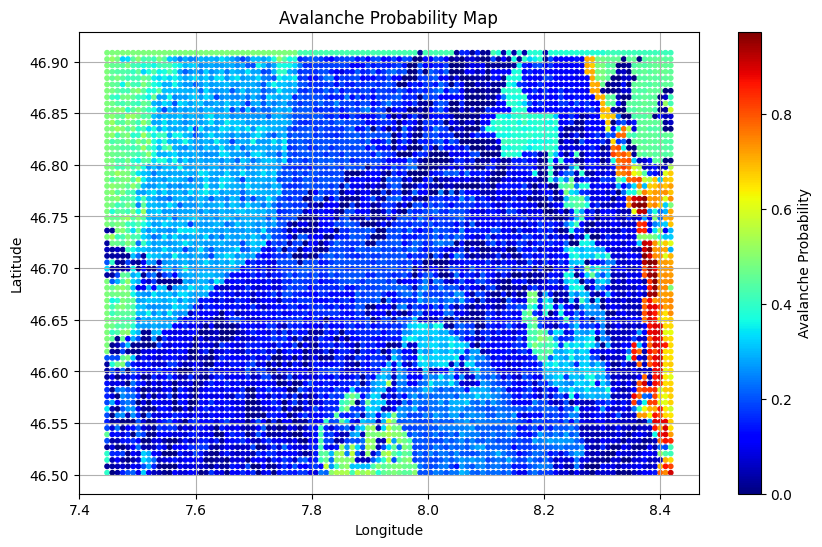

In [161]:

y_map_proba.shape

#PLOT 


# Plot
plt.figure(figsize=(10, 6))
sc = plt.scatter(lons, lats, c=y_map_proba, cmap='jet', s=10)
plt.colorbar(sc, label='Avalanche Probability')
plt.title('Avalanche Probability Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()



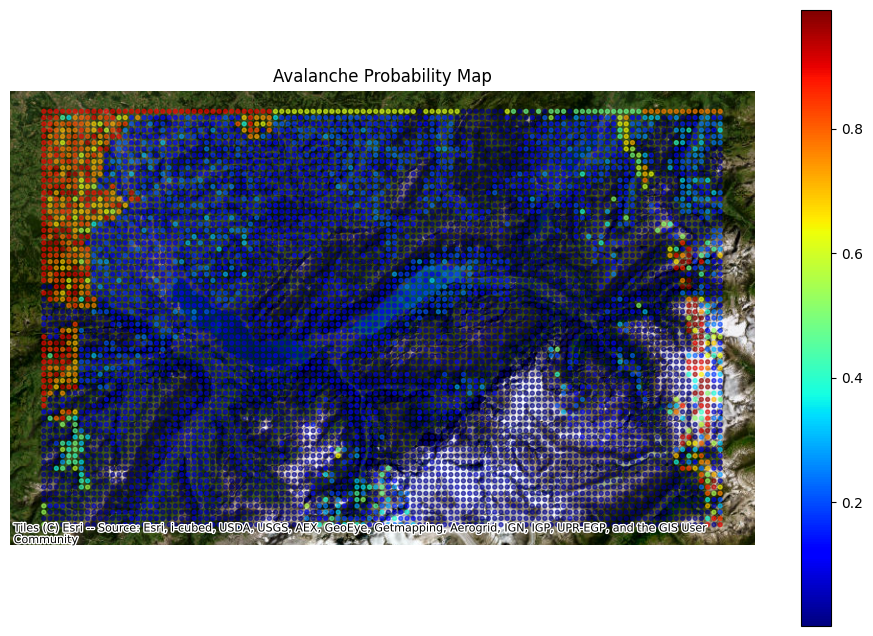

In [152]:
map_df = pd.read_csv("../Sat Data/test_image+stations.csv")


import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point, box
from scipy.interpolate import griddata
import pandas as pd

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
x_merc, y_merc = transformer.transform(map_df['lon'].values, map_df['lat'].values)

# Create a GeoDataFrame for plotting
gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(x_merc, y_merc),
    data={'proba': y_map_proba},
    crs="EPSG:3857"
)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot of prediction points
gdf.plot(
    ax=ax,
    column='proba',
    cmap='jet',
    markersize=8,
    legend=True,
    alpha=0.6
)

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, crs=gdf.crs)

ax.set_title("Avalanche Probability Map", fontsize=12)
ax.set_axis_off()

plt.show()

# Find important features in the F1 optimized

Index(['fkl010h3', 'dkl010h0', 'pva200h0', 'tde200h0', 'gradient_x',
       'gradient_y', 'fu3010h1', 'fkl010h0', 'gradient_magnitude', 'fu3010h3'],
      dtype='object')


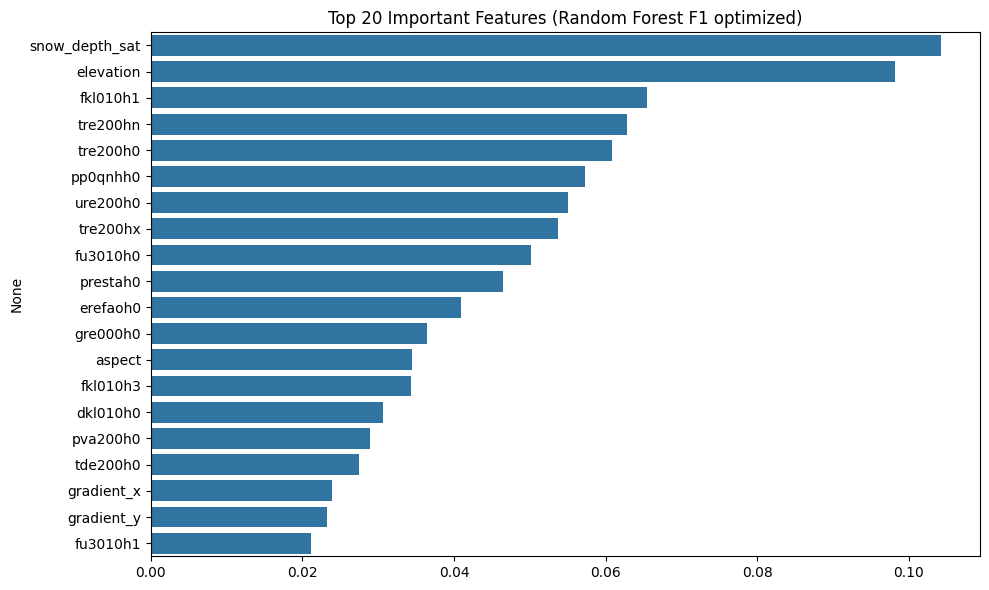

In [153]:
#Extract and visualizes the top 20 most important features used by your F1-optimized Random Forest model.
#Reflect how useful each feature is across all decisions the model makes — not just for one class.

importances = xgb_custom.feature_importances_
indices = np.argsort(importances)[::-1]
top_features = X_train.columns[indices][:20]

least_10 = X_train.columns[indices][-10:]
print(least_10)
# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:20], y=top_features)
plt.title("Top 20 Important Features (Random Forest F1 optimized)")
plt.tight_layout()
plt.show()

# Feature: Meaning / Why It Matters
# TSS_mod_daily: Snow surface temperature → affects melt/refreeze cycles
# OLWR_daily: Outgoing longwave radiation → linked to energy balance
# water_3_diff: Water content in layer 3 (deep snow) → potential instability
# TA_daily: Air temperature → critical for thawing/freezing
# ILWR / ILWR_daily: Incoming longwave radiation → heat exchange

#These features make sense in avalanche science 
#temperature, water content, and radiation balance are known triggers or indicators of unstable snowpack conditions

#!!
# Non-causal: These variables correlate with avalanche risk — they do not necessarily cause avalanches

# LIME - great for WHY ONE Prediction happened

In [22]:
#LIME = shows what pushed the prediction toward "Avalanche" or "No Avalanche" for a specific day

import lime
import lime.lime_tabular

# Create LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X.columns,
    class_names=['No Avalanche', 'Avalanche'],
    mode='classification'
)

# Choose a test instance to explain (e.g. the 5th test sample)
# LIME only explains one data point at a time
# X_test_scaled[i] == one specific test sample (a day with certain snow/weather values)
# runs LIME to explain why it was classified as either "Avalanche" or "No Avalanche"


### Correctly predicted avalanches

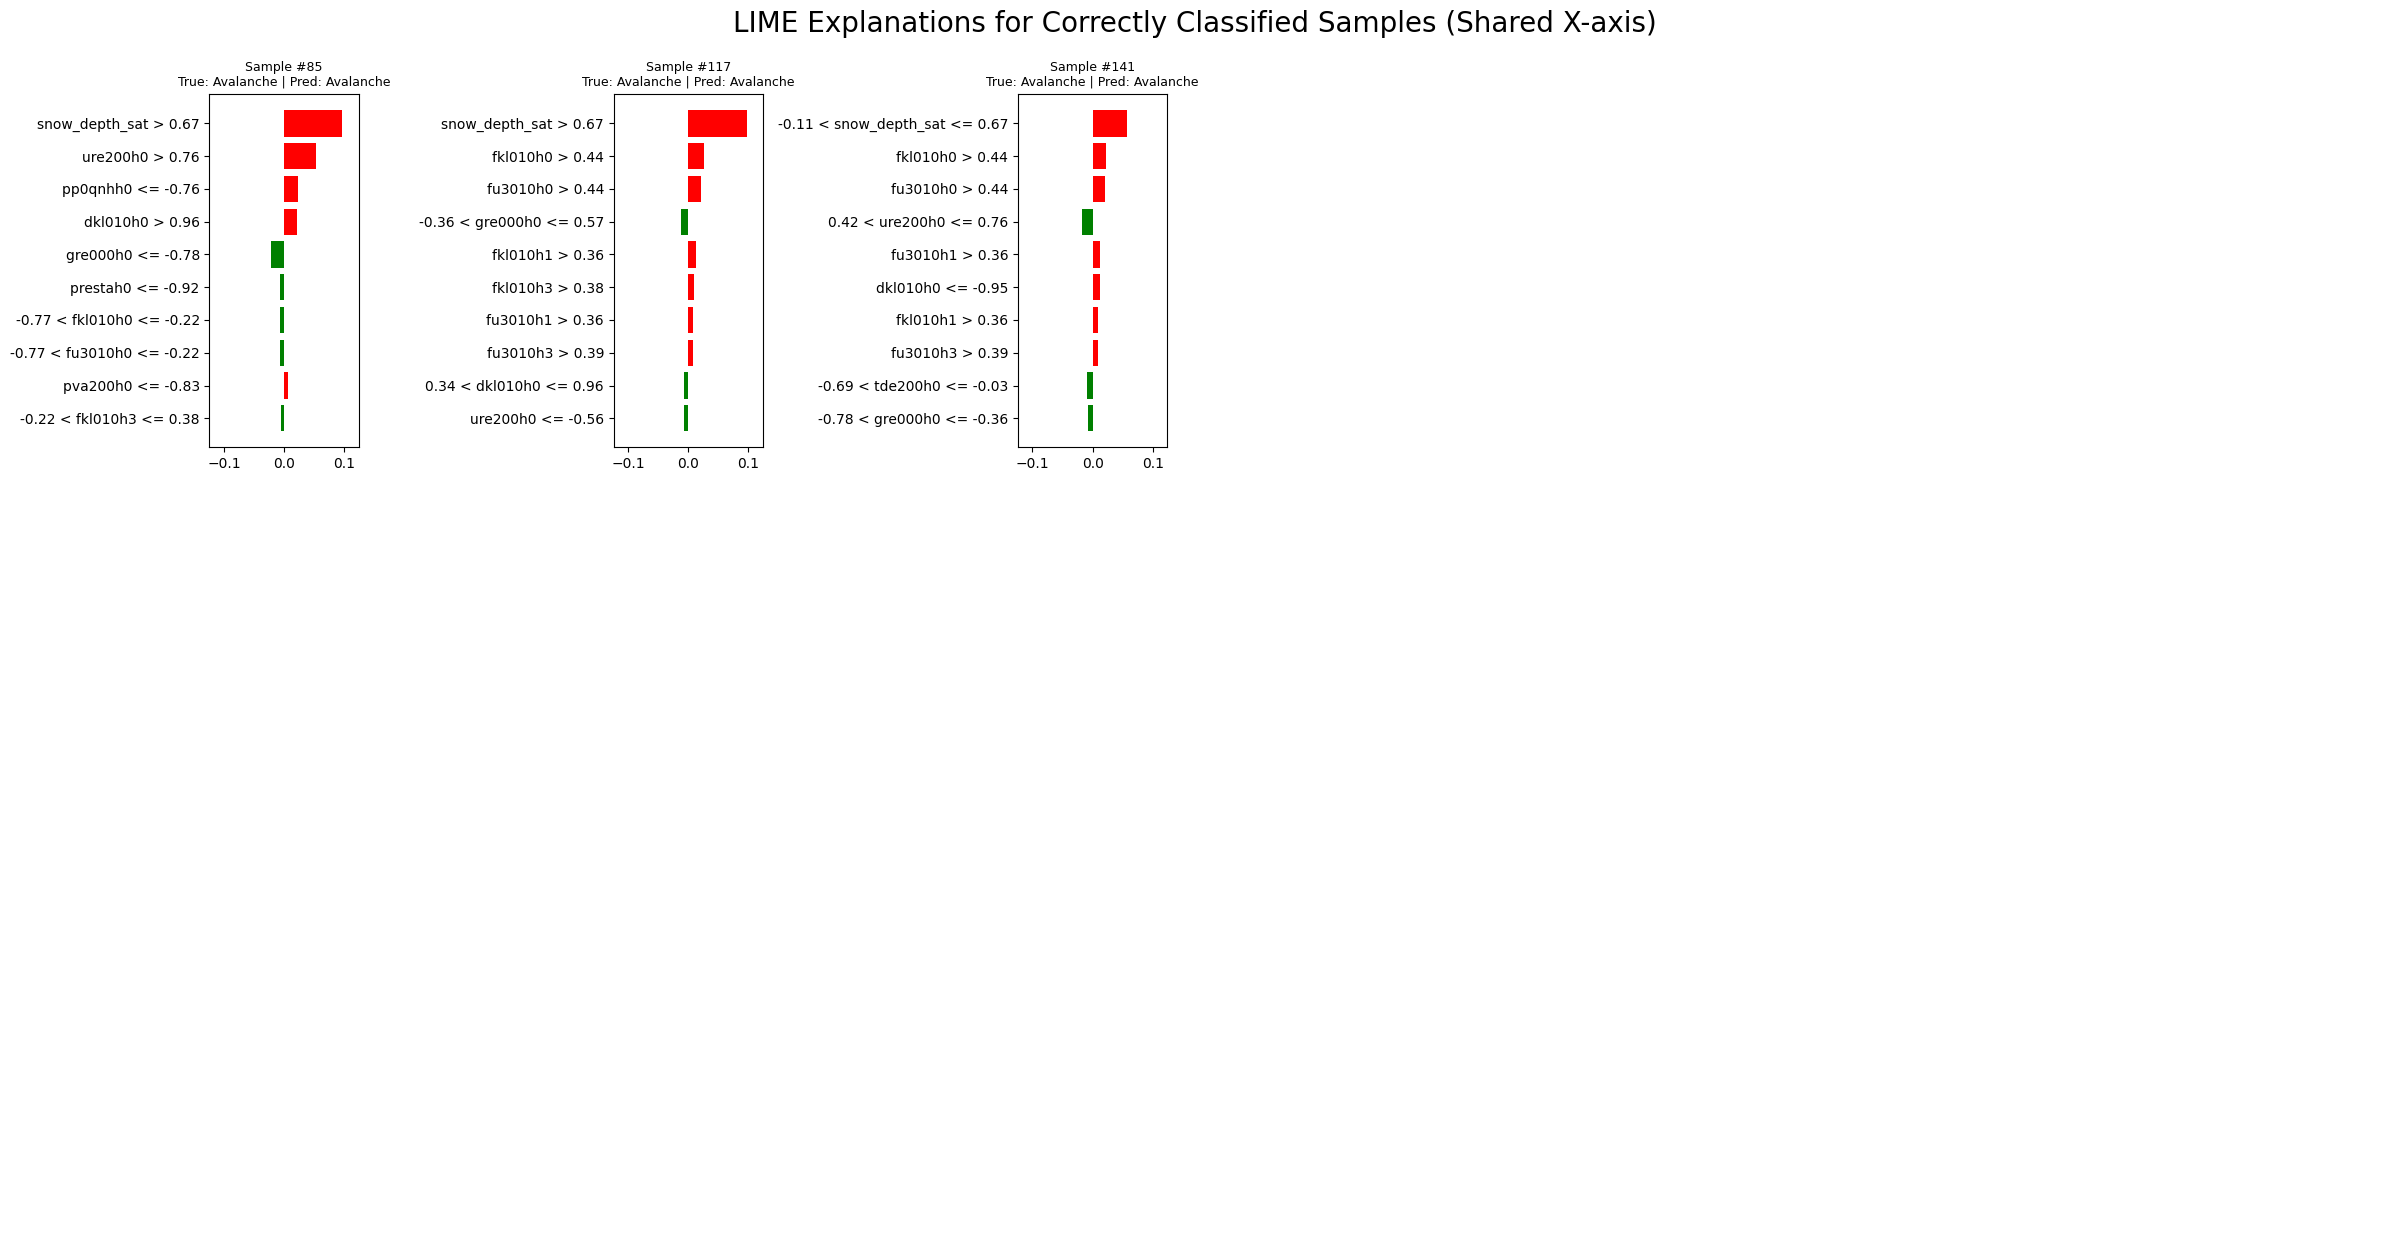

In [23]:
# Get indices of correctly predicted **Avalanche** samples (True Positives)
correct_indices = np.where((y_pred_F1 == 1) & (y_test.to_numpy() == 1))[0]

# Choose how many to plot
n_rows, n_cols = 3, 6
n_samples = min(len(correct_indices), n_rows * n_cols)
selected_indices = correct_indices[:n_samples]

# Step 1: Collect all weights to find shared x-axis range
all_weights = []
for i in selected_indices:
    exp = explainer.explain_instance(X_test_scaled[i], rf_custom_F1.predict_proba, num_features=10)
    weights = [w for _, w in exp.as_list(label=exp.available_labels()[0])]
    all_weights.extend(weights)

# Shared x-axis range
global_max = max(abs(w) for w in all_weights)

# Step 2: Create grid of LIME plots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 12))
axes = axes.flatten()

for idx, i in enumerate(selected_indices):
    true_label = y_test.iloc[i]
    predicted_label = y_pred_F1[i]

    exp = explainer.explain_instance(X_test_scaled[i], rf_custom_F1.predict_proba, num_features=10)
    explanation = exp.as_list(label=exp.available_labels()[0])
    features = [f for f, _ in explanation]
    weights = [w for _, w in explanation]

    # Horizontal bar plot
    axes[idx].barh(features, weights, color=["green" if w < 0 else "red" for w in weights])
    axes[idx].set_xlim(-global_max - 0.02, global_max + 0.02)
    axes[idx].set_title(
        f"Sample #{i}\nTrue: {'Avalanche' if true_label == 1 else 'No Avalanche'} | Pred: {'Avalanche' if predicted_label == 1 else 'No Avalanche'}",
        fontsize=9
    )
    axes[idx].invert_yaxis()

# Hide unused subplots
for j in range(n_samples, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle("LIME Explanations for Correctly Classified Samples (Shared X-axis)", fontsize=20, y=1.03)
plt.show()

### Factors in missclassifications

Number of misclassified samples: 20


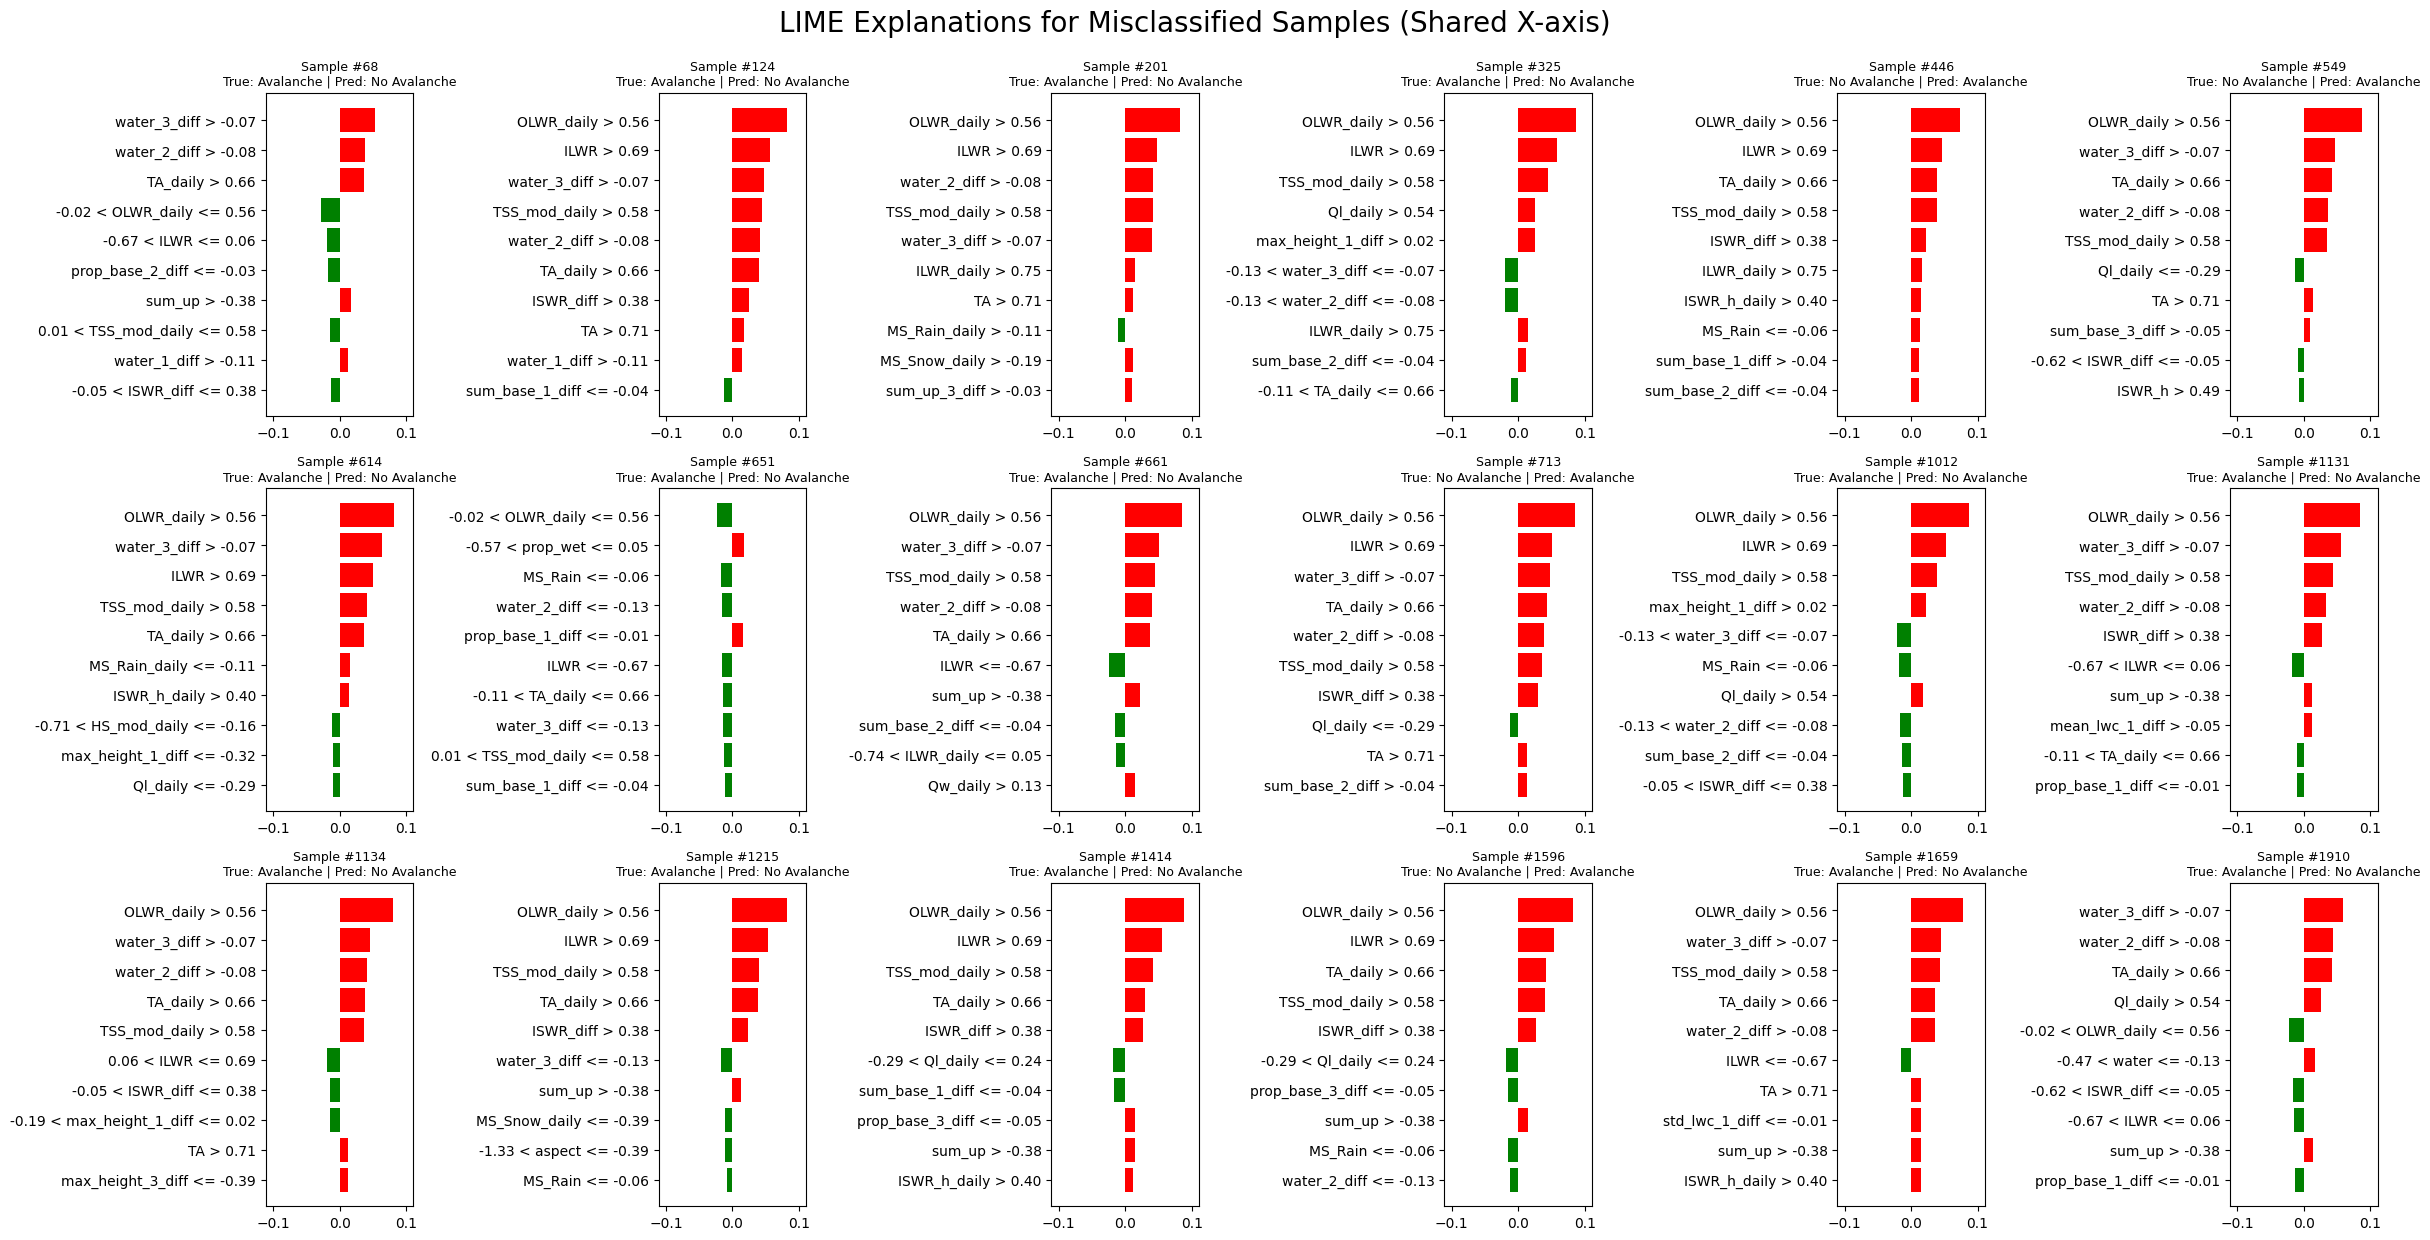

In [20]:
#Find missclassifications
y_test_array = y_test.to_numpy()
misclassified_indices = np.where(y_pred_F1 != y_test_array)[0]
print(f"Number of misclassified samples: {len(misclassified_indices)}") #found all 18

# Step 1: Collect all weights first to find global max
all_weights = []

for i in misclassified_indices:
    exp = explainer.explain_instance(X_test_scaled[i], rf_custom_F1.predict_proba, num_features=10)
    weights = [w for _, w in exp.as_list(label=exp.available_labels()[0])]
    all_weights.extend(weights)

# Step 2: Set consistent x-axis limits across all plots
global_max = max(abs(w) for w in all_weights)

# Step 3: Plot with shared x-limits
fig, axes = plt.subplots(3, 6, figsize=(24, 12))
axes = axes.flatten()

for idx, i in enumerate(misclassified_indices):
    if idx >= len(axes):
        break

    true_label = y_test.iloc[i]
    predicted_label = y_pred_F1[i]
    exp = explainer.explain_instance(X_test_scaled[i], rf_custom_F1.predict_proba, num_features=10)
    explanation = exp.as_list(label=exp.available_labels()[0])
    features = [x[0] for x in explanation]
    weights = [x[1] for x in explanation]

    axes[idx].barh(features, weights, color=['green' if w < 0 else 'red' for w in weights])
    axes[idx].set_xlim(-global_max - 0.02, global_max + 0.02)
    axes[idx].set_title(f"Sample #{i}\nTrue: {'Avalanche' if true_label == 1 else 'No Avalanche'} | Pred: {'Avalanche' if predicted_label == 1 else 'No Avalanche'}", fontsize=9)
    axes[idx].invert_yaxis()

# Hide unused subplots
for j in range(len(misclassified_indices), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle("LIME Explanations for Misclassified Samples (Shared X-axis)", fontsize=20, y=1.03)
plt.show()


# SHAP for global + local interpretation

SHAP shape:  (2059, 84, 2)
X_test_scaled_df shape:  (2059, 84)


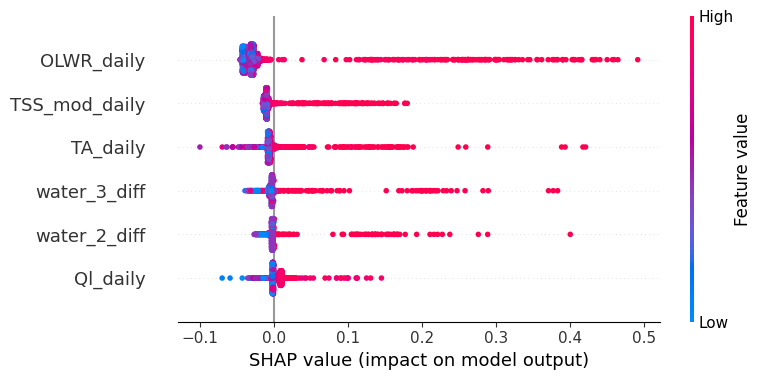

In [21]:
explainer = shap.TreeExplainer(rf_custom_F1)
# Convert test set back to DataFrame
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_scaled_df)
print("SHAP shape: ", shap_values.shape)
print("X_test_scaled_df shape: ", X_test_scaled_df.shape)

shap_values_class1 = shap_values[:, :, 1]  # class 1 = Avalanche

#Plot only the the top 6 features
shap.summary_plot(shap_values_class1, X_test_scaled_df, feature_names=X.columns, max_display=6)

#Ability to predict features 

Number of misclassified samples: 20

=== Misclassified Test Sample #68 ===
True Label     : Avalanche
Predicted Label: No Avalanche


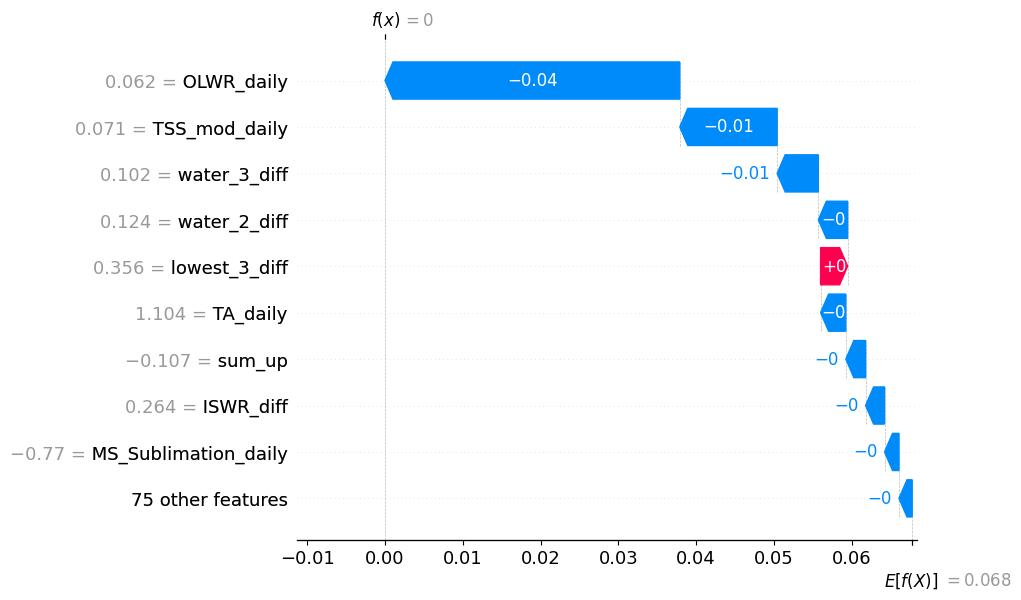


=== Misclassified Test Sample #124 ===
True Label     : Avalanche
Predicted Label: No Avalanche


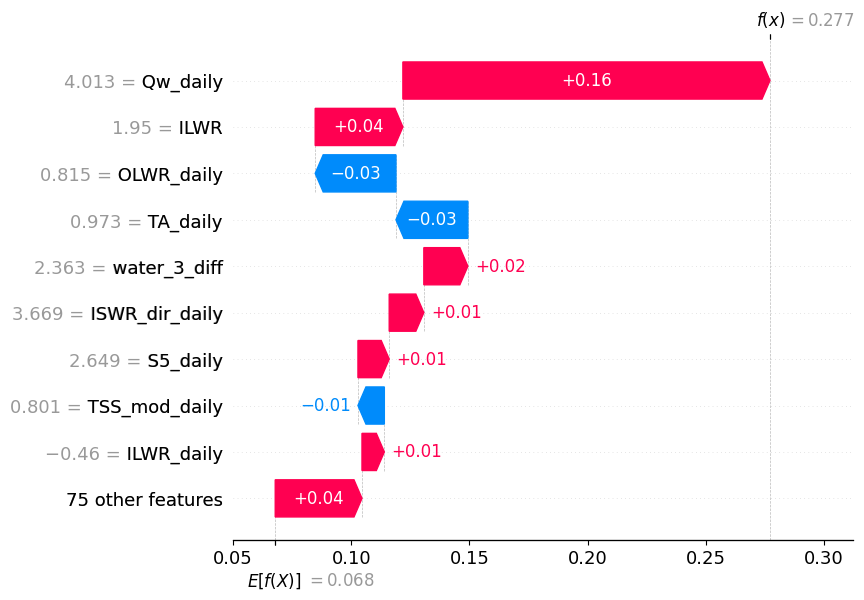


=== Misclassified Test Sample #201 ===
True Label     : Avalanche
Predicted Label: No Avalanche


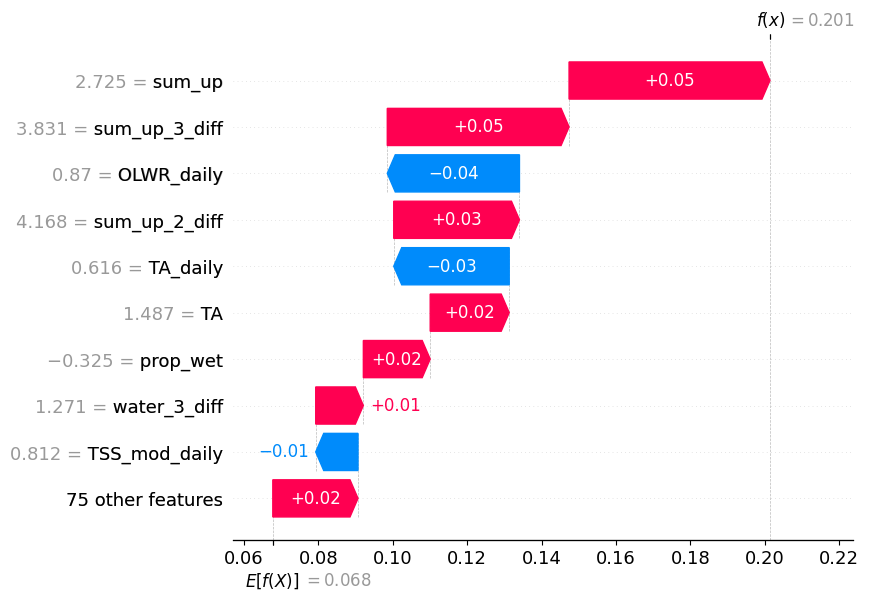


=== Misclassified Test Sample #325 ===
True Label     : Avalanche
Predicted Label: No Avalanche


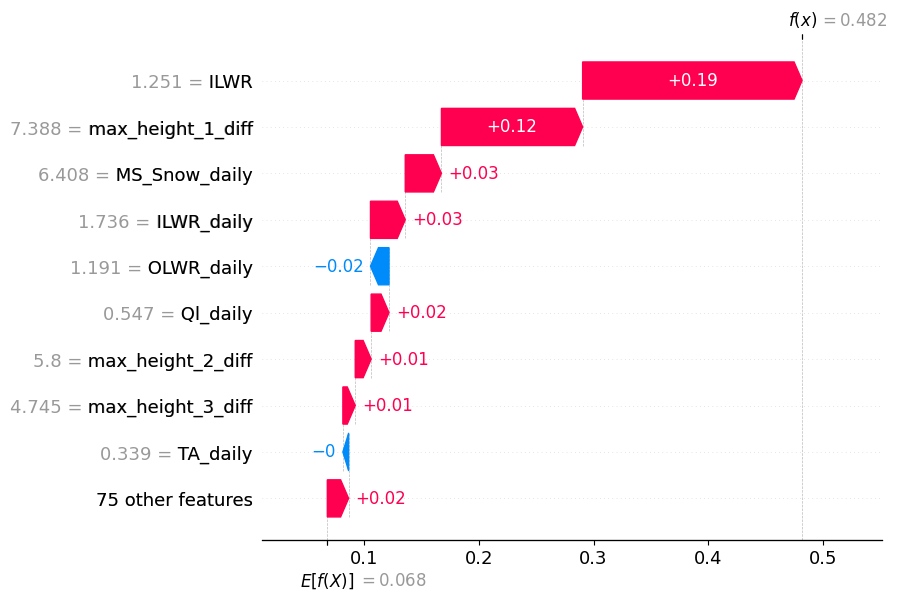


=== Misclassified Test Sample #446 ===
True Label     : No Avalanche
Predicted Label: Avalanche


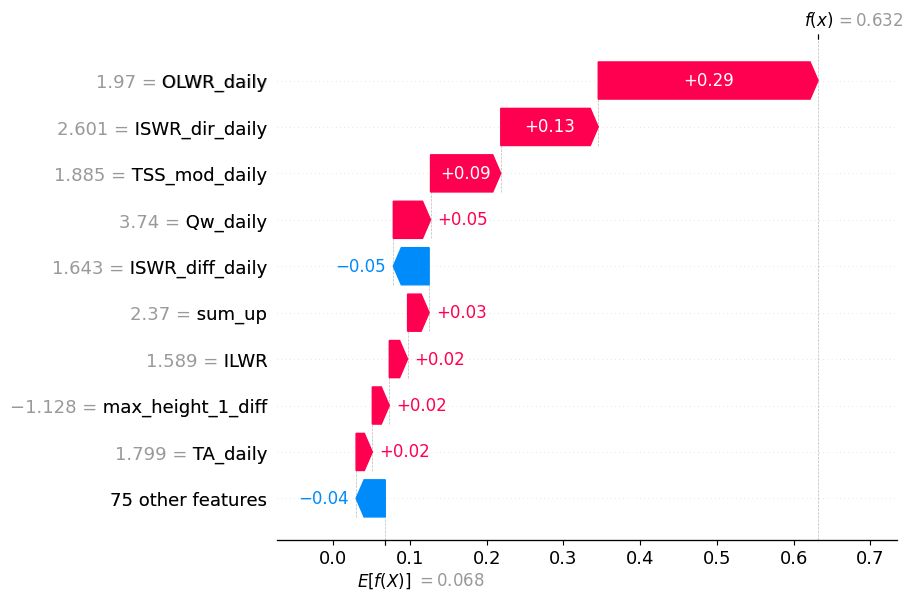


=== Misclassified Test Sample #549 ===
True Label     : No Avalanche
Predicted Label: Avalanche


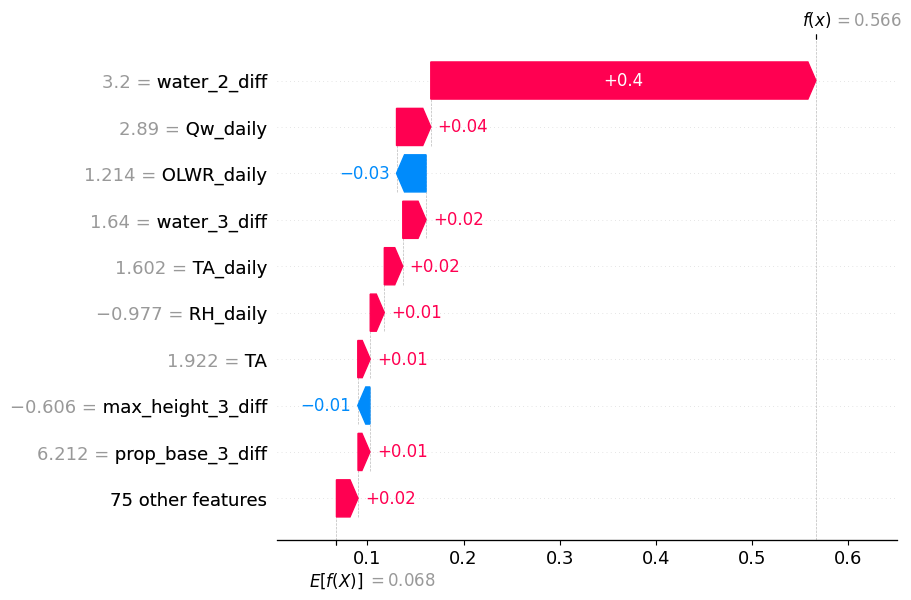


=== Misclassified Test Sample #614 ===
True Label     : Avalanche
Predicted Label: No Avalanche


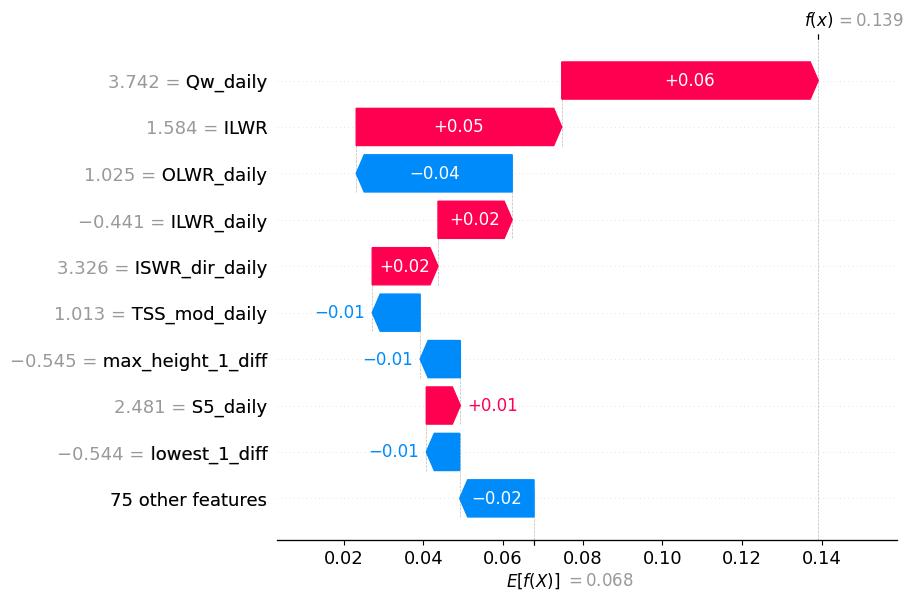


=== Misclassified Test Sample #651 ===
True Label     : Avalanche
Predicted Label: No Avalanche


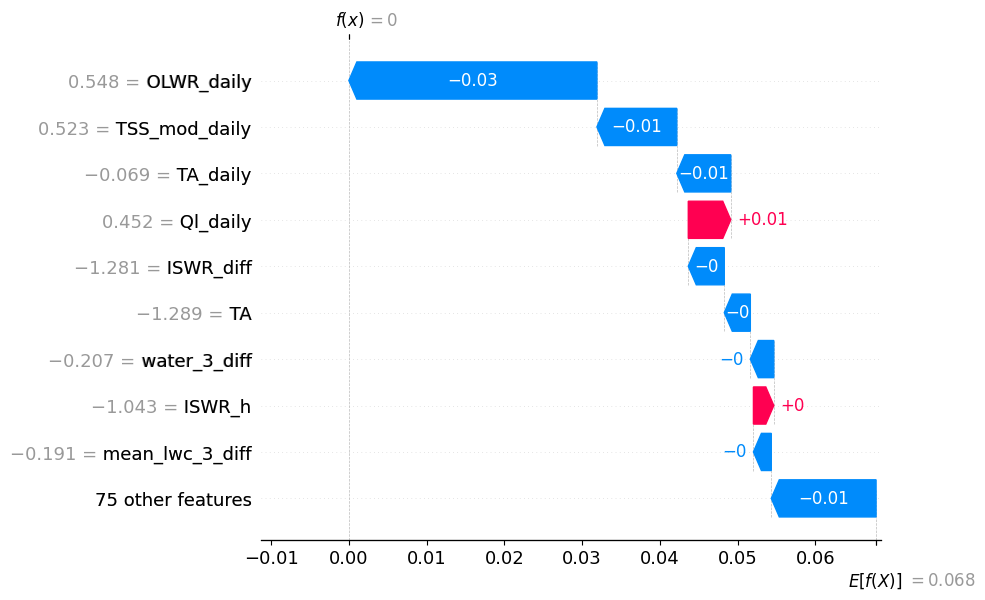


=== Misclassified Test Sample #661 ===
True Label     : Avalanche
Predicted Label: No Avalanche


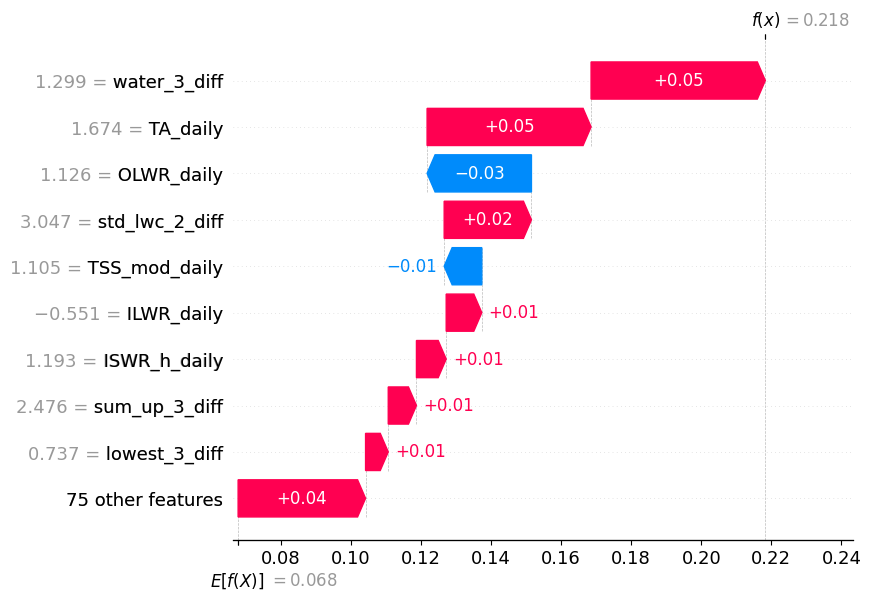


=== Misclassified Test Sample #713 ===
True Label     : No Avalanche
Predicted Label: Avalanche


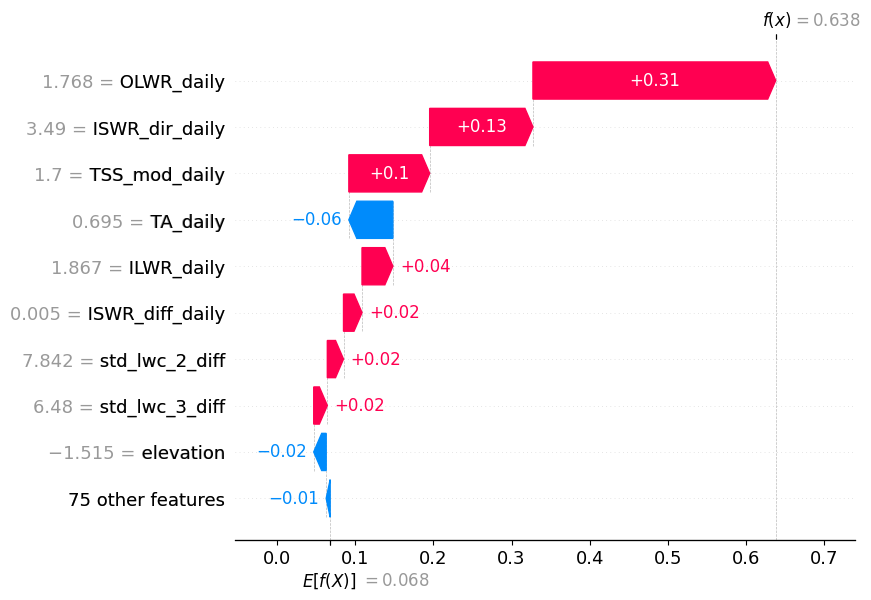


=== Misclassified Test Sample #1012 ===
True Label     : Avalanche
Predicted Label: No Avalanche


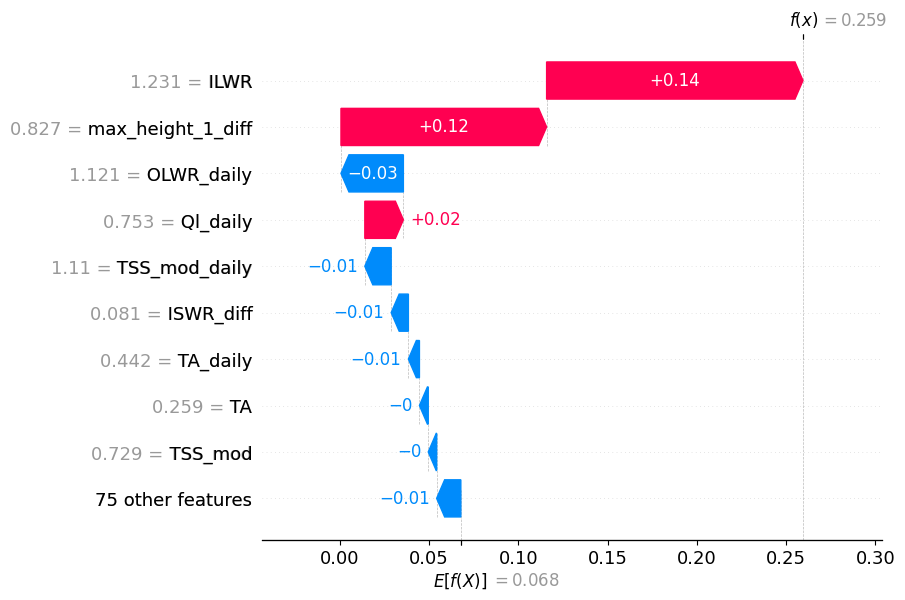


=== Misclassified Test Sample #1131 ===
True Label     : Avalanche
Predicted Label: No Avalanche


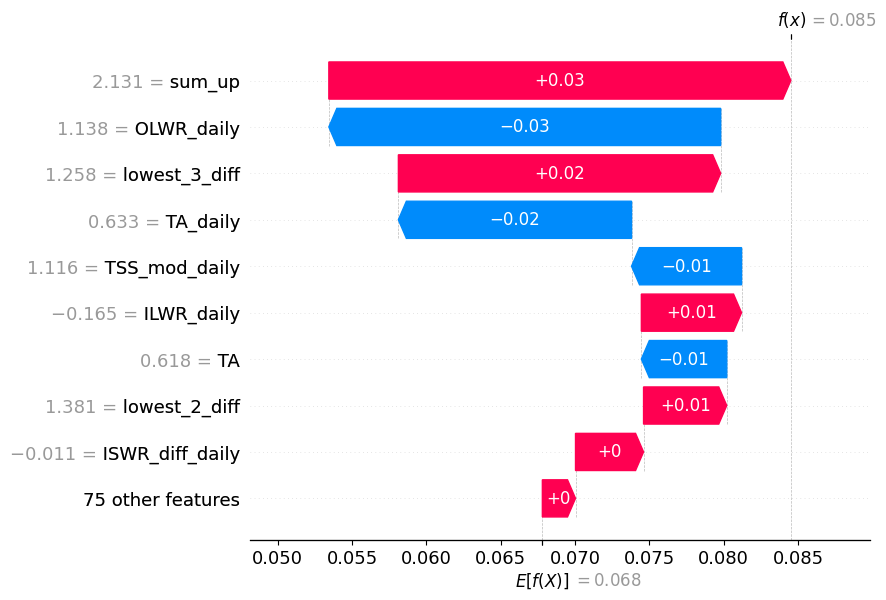


=== Misclassified Test Sample #1134 ===
True Label     : Avalanche
Predicted Label: No Avalanche


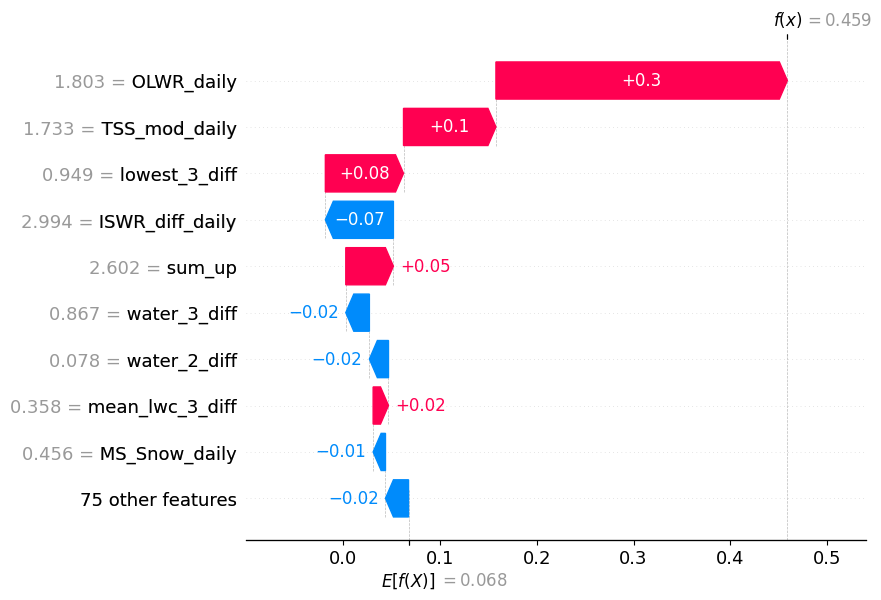


=== Misclassified Test Sample #1215 ===
True Label     : Avalanche
Predicted Label: No Avalanche


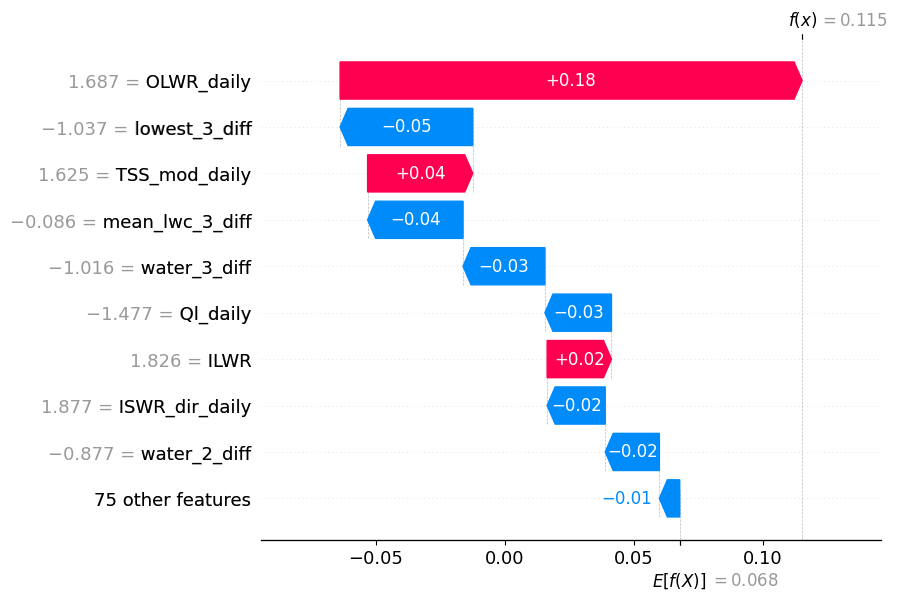


=== Misclassified Test Sample #1414 ===
True Label     : Avalanche
Predicted Label: No Avalanche


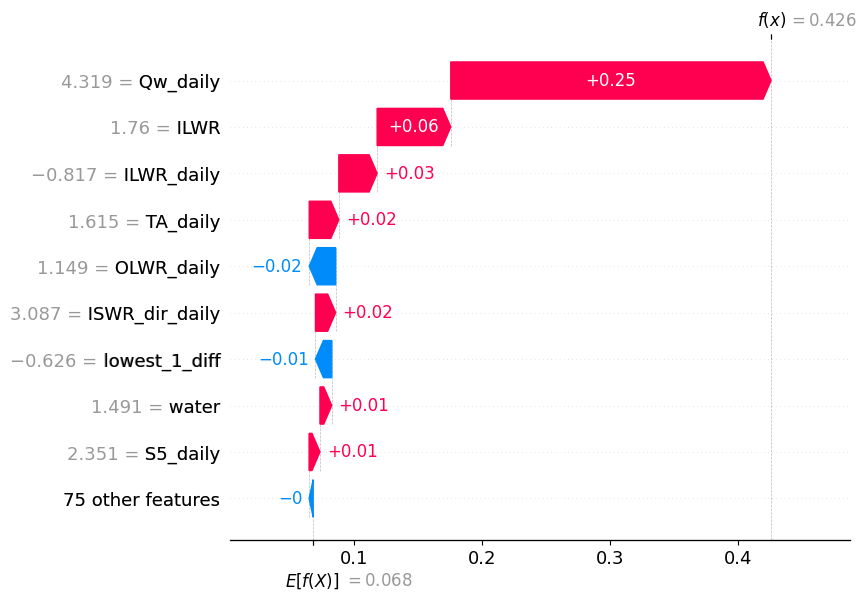


=== Misclassified Test Sample #1596 ===
True Label     : No Avalanche
Predicted Label: Avalanche


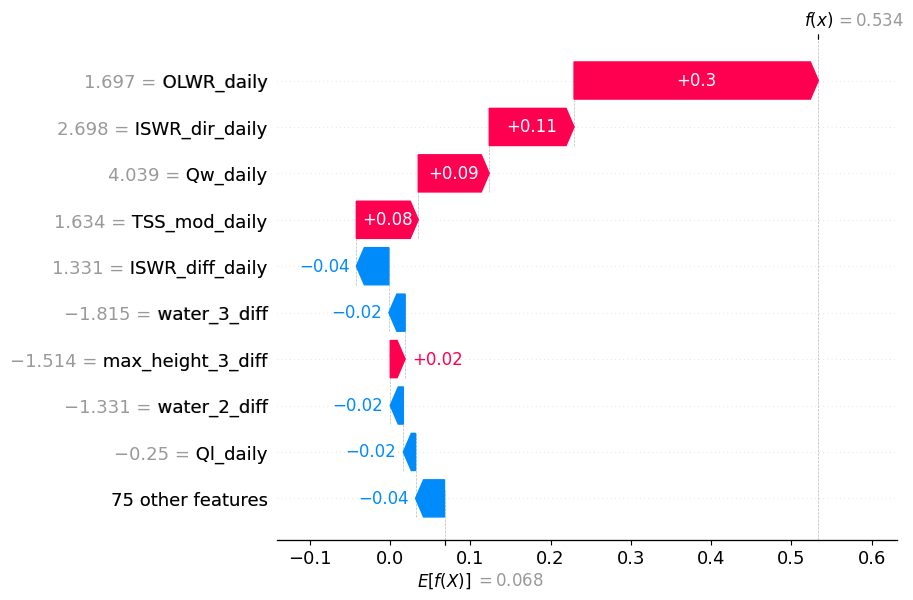


=== Misclassified Test Sample #1659 ===
True Label     : Avalanche
Predicted Label: No Avalanche


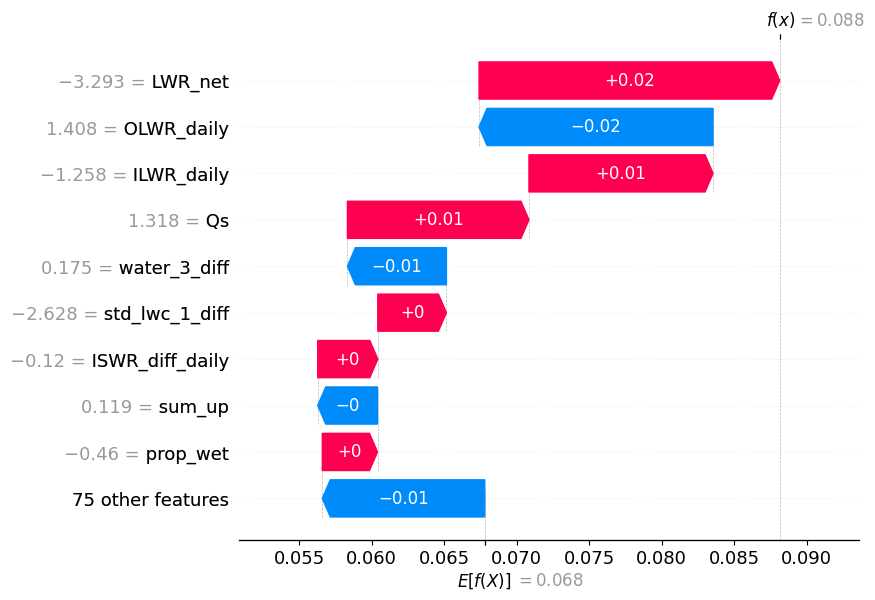


=== Misclassified Test Sample #1910 ===
True Label     : Avalanche
Predicted Label: No Avalanche


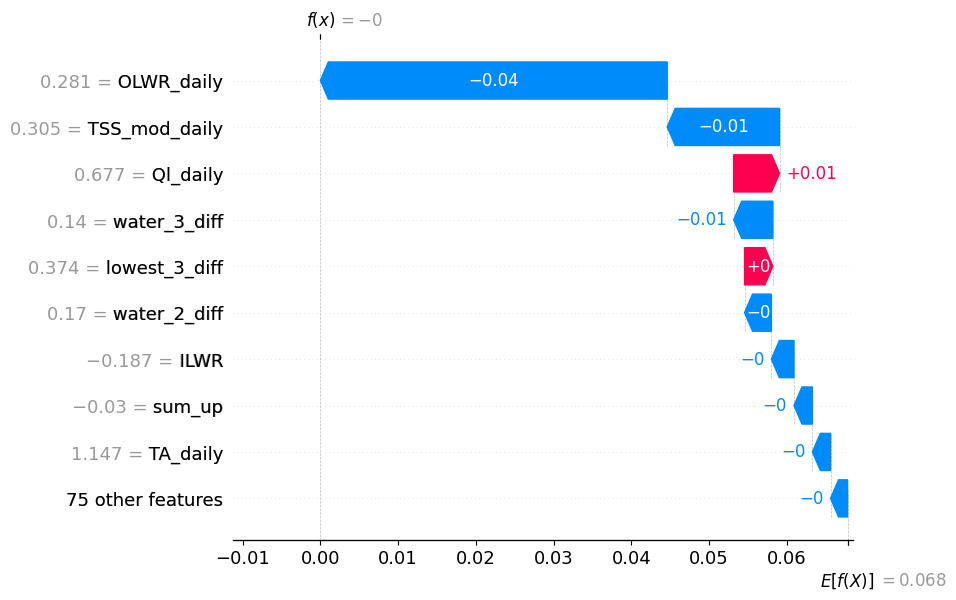


=== Misclassified Test Sample #1930 ===
True Label     : Avalanche
Predicted Label: No Avalanche


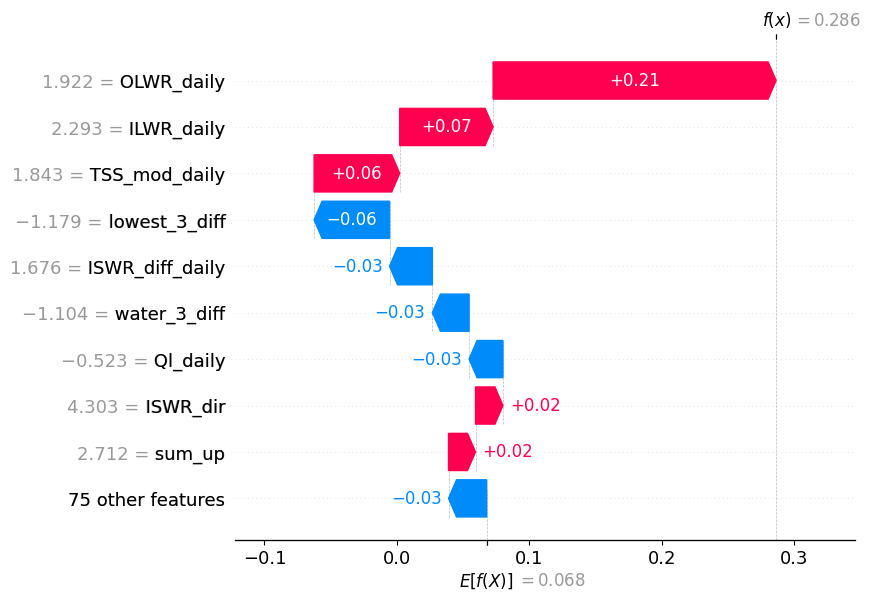


=== Misclassified Test Sample #2047 ===
True Label     : Avalanche
Predicted Label: No Avalanche


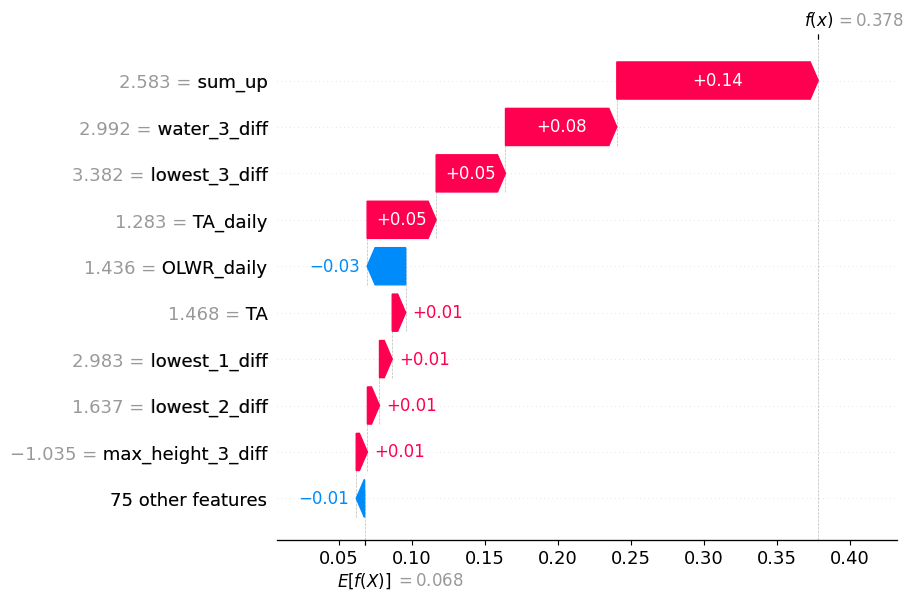

In [22]:
shap.initjs()

# Convert y_test to NumPy array and align index
y_test_array = y_test.reset_index(drop=True).to_numpy()
misclassified_indices = np.where(y_pred_F1 != y_test_array)[0]
print(f"Number of misclassified samples: {len(misclassified_indices)}")

# Loop through misclassified samples
for i in misclassified_indices:
    print(f"\n=== Misclassified Test Sample #{i} ===")
    true_label = y_test_array[i]
    predicted_label = y_pred_F1[i]
    print(f"True Label     : {'Avalanche' if true_label == 1 else 'No Avalanche'}")
    print(f"Predicted Label: {'Avalanche' if predicted_label == 1 else 'No Avalanche'}")

    shap_values_single = shap_values_class1[i]  # shape: (n_features,)
    sample = X_test_scaled_df.iloc[i]

    # Build SHAP Explanation object
    explanation = shap.Explanation(
        values=shap_values_single,
        base_values=explainer.expected_value[1],
        data=sample.values,
        feature_names=X.columns
    )

    shap.plots.waterfall(explanation)